In [2]:
# 1) Imports
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from imblearn.over_sampling import RandomOverSampler

In [3]:
# Configuration
DATA_PATH = "career_ready_dataset_final.csv"   # <-- change if your filename differs
TEXT_COL = "combined"                          # use provided 'combined' column explicitly
TARGET_COL = "career"                          # target column
DROP_OTHER = True                              # drop rows where career == 'other'
MIN_SAMPLES = 5                                # drop classes with fewer than MIN_SAMPLES
MERGE_SIMILAR = True                           # whether to merge similar labels (optional)

In [4]:
MODEL_PKL = "career_rf_model.pkl"
VECTORIZER_PKL = "career_tfidf.pkl"
ENCODER_PKL = "career_label_encoder.pkl"


In [5]:
# Merge mapping - edit if you want different merges
MERGE_MAPPING = {
    'software developer': 'software engineer',
    'software dev': 'software engineer',
    'software engg': 'software engineer',
    'mechanical engineer': 'engineer',
    'electronics engineer': 'engineer',
    'electronics and communication engineer': 'engineer',
    'automobile engineer': 'engineer',
    'telecom engineer': 'engineer',
    'business analyst': 'data analyst'
}

In [6]:
# 3) Load dataset and validate columns
df = pd.read_csv('career_ready_dataset_final.csv')
print("Dataset loaded:", df.shape)
print("Columns present:", df.columns.tolist())


Dataset loaded: (1195, 7)
Columns present: ['course', 'specialization', 'interests', 'skills', 'combined', 'course_spec', 'career']


In [7]:
if TEXT_COL not in df.columns or TARGET_COL not in df.columns:
    raise ValueError(f"Required columns not found. Expected TEXT_COL='{TEXT_COL}', TARGET_COL='{TARGET_COL}'")

In [8]:
# 4) Basic cleaning: keep only needed columns, drop nulls/empty combined text
df = df[[TEXT_COL, TARGET_COL]].dropna().reset_index(drop=True)
df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip().str.lower()
df = df[df[TEXT_COL] != ""].reset_index(drop=True)
print("After dropping null/empty combined text:", df.shape)


After dropping null/empty combined text: (1195, 2)


In [9]:
# 5) Handle 'other' and merge similar labels
print("\nOriginal class distribution (top 30):")
print(df[TARGET_COL].value_counts().head(30))



Original class distribution (top 30):
career
software engineer                         275
engineer                                  179
other                                     133
accountant                                 84
mechanical engineer                        72
electronics and communication engineer     71
data analyst                               66
automobile engineer                        50
civil engineer                             38
business analyst                           25
research scientist                         20
marketing executive                        19
teacher                                    15
telecom engineer                           13
civil services aspirant                    11
content writer                             11
financial analyst                          10
biotech researcher                         10
biologist                                  10
software developer                          9
chemist                           

In [10]:
if DROP_OTHER and 'other' in df[TARGET_COL].unique():
    print("\nDropping 'other' class (DROP_OTHER=True).")
    df = df[df[TARGET_COL] != 'other'].reset_index(drop=True)
else:
    print("\nKeeping 'other' class (DROP_OTHER=False).")



Dropping 'other' class (DROP_OTHER=True).


In [12]:
if MERGE_SIMILAR:
    print("\nApplying MERGE_MAPPING to merge similar labels.")
    df[TARGET_COL] = df[TARGET_COL].replace(MERGE_MAPPING)
    print("Distribution after merge (top 30):")
    print(df[TARGET_COL].value_counts().head(30))


Applying MERGE_MAPPING to merge similar labels.
Distribution after merge (top 30):
career
engineer                   385
software engineer          284
data analyst                91
accountant                  84
civil engineer              38
research scientist          20
marketing executive         19
teacher                     15
civil services aspirant     11
content writer              11
biotech researcher          10
financial analyst           10
biologist                   10
chemist                      8
lawyer                       8
electrical engineer          7
designer                     6
hr executive                 5
psychologist                 5
agricultural officer         4
journalist                   4
gis analyst                  3
chemical engineer            3
social researcher            3
pharmacist                   3
marketing manager            3
automation engineer          3
aerospace engineer           2
architect                    2
economist 

In [13]:
# 6) Remove very rare classes (fewer than MIN_SAMPLES)
vc = df[TARGET_COL].value_counts()
rare = vc[vc < MIN_SAMPLES]
if len(rare) > 0:
    print(f"\nRemoving {len(rare)} classes with fewer than {MIN_SAMPLES} samples:")
    print(rare.index.tolist())
    df = df[df[TARGET_COL].isin(vc[vc >= MIN_SAMPLES].index)].reset_index(drop=True)
else:
    print(f"\nNo classes with fewer than {MIN_SAMPLES} samples.")

print("\nClass distribution after cleaning (top 30):")
print(df[TARGET_COL].value_counts().head(30))
print("Total samples remaining:", len(df))


Removing 13 classes with fewer than 5 samples:
['agricultural officer', 'journalist', 'gis analyst', 'chemical engineer', 'social researcher', 'pharmacist', 'marketing manager', 'automation engineer', 'aerospace engineer', 'architect', 'economist', 'web developer', 'business manager']

Class distribution after cleaning (top 30):
career
engineer                   385
software engineer          284
data analyst                91
accountant                  84
civil engineer              38
research scientist          20
marketing executive         19
teacher                     15
civil services aspirant     11
content writer              11
financial analyst           10
biologist                   10
biotech researcher          10
lawyer                       8
chemist                      8
electrical engineer          7
designer                     6
psychologist                 5
hr executive                 5
Name: count, dtype: int64
Total samples remaining: 1027


In [14]:
# 7) Label encoding
le = LabelEncoder()
y = le.fit_transform(df[TARGET_COL])
print("\nEncoded classes count:", len(le.classes_))
print("Classes:", list(le.classes_))


Encoded classes count: 19
Classes: ['accountant', 'biologist', 'biotech researcher', 'chemist', 'civil engineer', 'civil services aspirant', 'content writer', 'data analyst', 'designer', 'electrical engineer', 'engineer', 'financial analyst', 'hr executive', 'lawyer', 'marketing executive', 'psychologist', 'research scientist', 'software engineer', 'teacher']


In [15]:
# 8) Train-test split (important: BEFORE TF-IDF and BEFORE oversampling)
X = df[TEXT_COL].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTrain / Test sizes:", len(X_train), "/", len(X_test))


Train / Test sizes: 821 / 206


In [16]:

# 9) TF-IDF vectorization (fit only on training set)
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1,2),
    max_df=0.9,
    min_df=2,
    max_features=20000
)

In [20]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("\nTF-IDF shapes -> Train:", X_train_tfidf.shape, " Test:", X_test_tfidf.shape)



TF-IDF shapes -> Train: (821, 1328)  Test: (206, 1328)


In [21]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("\nTF-IDF shapes -> Train:", X_train_tfidf.shape, " Test:", X_test_tfidf.shape)



TF-IDF shapes -> Train: (821, 1328)  Test: (206, 1328)


In [22]:
# 10) Oversample training set only to balance classes
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_tfidf, y_train)
print("\nAfter oversampling, train shape:", X_train_res.shape)
unique, counts = np.unique(y_train_res, return_counts=True)
print("Resampled class counts (examples):")
for idx, cnt in zip(unique[:10], counts[:10]):
    print(f"  {le.inverse_transform([idx])[0]}: {cnt}")


After oversampling, train shape: (5852, 1328)
Resampled class counts (examples):
  accountant: 308
  biologist: 308
  biotech researcher: 308
  chemist: 308
  civil engineer: 308
  civil services aspirant: 308
  content writer: 308
  data analyst: 308
  designer: 308
  electrical engineer: 308


In [23]:
# 11) Train Random Forest (no pipeline)
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced_subsample',
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)
print("\nRandom Forest training completed.")



Random Forest training completed.


In [24]:
# 12) Evaluate on test set (truthfully unseen)
y_pred = rf.predict(X_test_tfidf)


In [25]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)


In [26]:
print("\nOverall evaluation metrics:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")


Overall evaluation metrics:
Accuracy:  0.8786
Precision: 0.8682
Recall:    0.8786
F1-score:  0.8680


In [27]:
print("\nClassification report (per-class):")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))



Classification report (per-class):
                         precision    recall  f1-score   support

             accountant       0.83      0.88      0.86        17
              biologist       0.67      1.00      0.80         2
     biotech researcher       1.00      1.00      1.00         2
                chemist       1.00      1.00      1.00         2
         civil engineer       0.80      1.00      0.89         8
civil services aspirant       1.00      1.00      1.00         2
         content writer       1.00      0.50      0.67         2
           data analyst       0.58      0.78      0.67        18
               designer       0.00      0.00      0.00         1
    electrical engineer       0.00      0.00      0.00         1
               engineer       0.99      0.99      0.99        77
      financial analyst       0.00      0.00      0.00         2
           hr executive       0.00      0.00      0.00         1
                 lawyer       0.50      0.50      0.5

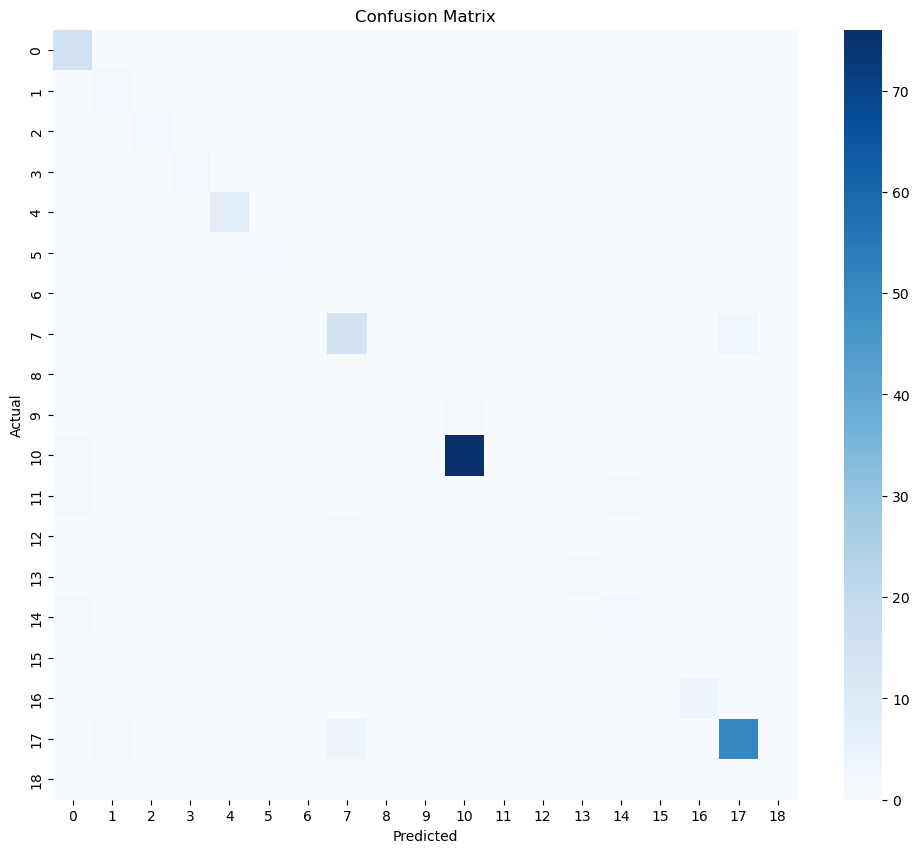

In [28]:
# 13) Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap='Blues', cbar=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [37]:
# 14) Feature importance (map back to TF-IDF terms)
try:
    importances = rf.feature_importances_
    if importances.sum() > 0:
        vocab = tfidf.get_feature_names_out()
        top_n = 20
        top_indices = np.argsort(importances)[-top_n:][::-1]
        print("\nTop TF-IDF features by RandomForest importance:")
        for i in top_indices:
            print(f"{vocab[i]:30s} --> {importances[i]:.6f}")
except Exception as e:
    print("Could not compute feature importances:", e)


Top TF-IDF features by RandomForest importance:
physics                        --> 0.030109
engineering                    --> 0.023552
english                        --> 0.021781
psychology                     --> 0.020989
chemistry                      --> 0.020220
biotechnology                  --> 0.017568
political science              --> 0.017403
political                      --> 0.017114
marketing                      --> 0.016391
electrical                     --> 0.015685
history                        --> 0.015679
science                        --> 0.013299
finance                        --> 0.013271
civil engineering              --> 0.012682
computer                       --> 0.012387
tech civil                     --> 0.012126
civil                          --> 0.011384
sc chemistry                   --> 0.010508
law                            --> 0.010089
ba                             --> 0.008909


In [38]:
# 15) Save model, vectorizer, encoder
with open(MODEL_PKL, "wb") as f:
    pickle.dump(rf, f)
with open(VECTORIZER_PKL, "wb") as f:
    pickle.dump(tfidf, f)
with open(ENCODER_PKL, "wb") as f:
    pickle.dump(le, f)

print(f"\nSaved files: {MODEL_PKL}, {VECTORIZER_PKL}, {ENCODER_PKL}")


Saved files: career_rf_model.pkl, career_tfidf.pkl, career_label_encoder.pkl


In [39]:
# 16) Quick sample prediction (simulate API)
def predict_career(text):
    vec = tfidf.transform([text])
    pred_idx = rf.predict(vec)[0]
    label = le.inverse_transform([pred_idx])[0]
    proba = rf.predict_proba(vec)[0] if hasattr(rf, "predict_proba") else None
    return label, proba

In [40]:
sample_text = "b.tech computer science python sql machine learning data analysis"
pred_label, pred_proba = predict_career(sample_text)
print("\nSample input:", sample_text)
print("Predicted career:", pred_label)
if pred_proba is not None:
    print("Top probabilities (first 10):", pred_proba[:10])



Sample input: b.tech computer science python sql machine learning data analysis
Predicted career: software engineer
Top probabilities (first 10): [0.02333333 0.         0.00333333 0.00333333 0.         0.01333333
 0.         0.09333333 0.01       0.        ]
